# EWS segmentation finetune (MAE + UNet decoder)

Switch **`MAE_BACKEND`** in the config cell: **`"vanilla"`** (default `mae2d` + `train_seg`) or **`"geom"`** (`MaskedAutoencoder2DGeom` + `train_seg_geom`). Original scripts stay runnable; only this notebook branches.

Data **only** from **`EWS/data/EWS-Dataset`** splits **train / validation / test** (same as `train_seg.py`).

MAE init:

- **`USE_PRETRAINED_MAE = True`**: load ckpt — vanilla uses **`MAE_CKPT_REL`**; geom uses **`MAE_GEOM_CKPT_REL`** (e.g. `mae2d_geom_best.pt`).
- **`USE_PRETRAINED_MAE = False`**: random MAE init; geom path respects **`USE_GEOM_BIAS_RANDOM`**.

Supervised **`BCEWithLogits`**; metrics Dice / pixel Acc / pixel ROC-AUC. CSV: `segmentation_training_log.csv` vs `segmentation_training_log_geom.csv`; checkpoints under **`OUT_DIR_REL`** or **`OUT_DIR_GEOM_REL`**.

Requires: `torch`, `tqdm`, `matplotlib`; optional `scikit-learn`. Last cells: test viz (grayscale masks).


In [6]:
# ========== Config ==========
MAE_BACKEND = "geom"  # "vanilla" | "geom"

USE_PRETRAINED_MAE = True  # True: load MAE ckpt; False: random MAE init

MAE_CKPT_REL = "EWS/data/pretrain/checkpoints/mae2d_best.pt"
MAE_GEOM_CKPT_REL = "EWS/data/pretrain/checkpoints_geom/mae2d_geom_best.pt"
EWS_DATASET_REL = "EWS/data/EWS-Dataset"

# Random init + MAE_BACKEND=="geom": match pretrain use_geom_bias
USE_GEOM_BIAS_RANDOM = True

IMG_SIZE = 350
PATCH_SIZE = 5
EPOCHS = 20
BATCH_SIZE = 1
LR = 3e-4
WEIGHT_DECAY = 0.01
NUM_WORKERS = 2
FREEZE_MAE = False
USE_AMP = True
RUN_TEST_ON_FINISH = True

OUT_DIR_REL = "EWS/data/finetune_seg_ckpts_notebook"
OUT_DIR_GEOM_REL = "EWS/data/finetune_seg_ckpts_notebook_geom"

VIZ_TEST_INDEX = 0
VIZ_MASK_THRESHOLD = 0.5


In [7]:
from pathlib import Path
import sys


def find_repo(start: Path) -> Path:
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "EWS" / "finetune" / "train_seg.py").is_file():
            return p
    raise FileNotFoundError("Open this notebook inside AR-SSL4M repo.")


REPO = find_repo(Path.cwd())
FIN = REPO / "EWS" / "finetune"
PRE = REPO / "EWS" / "pretrain"
sys.path.insert(0, str(FIN))
sys.path.insert(0, str(PRE))

if MAE_BACKEND == "geom":
    MAE_CKPT = (REPO / MAE_GEOM_CKPT_REL).resolve()
    OUT_DIR = (REPO / OUT_DIR_GEOM_REL).resolve()
    LOG_CSV_NAME = "segmentation_training_log_geom.csv"
    SEG_BEST_NAME = "unet_mae_geom_best.pt"
    SEG_EPOCH_PREFIX = "unet_mae_geom_epoch"
    TEST_METRICS_TXT = "test_metrics_notebook_geom.txt"
else:
    MAE_CKPT = (REPO / MAE_CKPT_REL).resolve()
    OUT_DIR = (REPO / OUT_DIR_REL).resolve()
    LOG_CSV_NAME = "segmentation_training_log.csv"
    SEG_BEST_NAME = "unet_mae_best.pt"
    SEG_EPOCH_PREFIX = "unet_mae_epoch"
    TEST_METRICS_TXT = "test_metrics_notebook.txt"

EWS_DATA_ROOT = (REPO / EWS_DATASET_REL).resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("REPO:", REPO)
print("MAE_BACKEND:", MAE_BACKEND)
print("MAE_CKPT:", MAE_CKPT)
print("OUT_DIR:", OUT_DIR)


REPO: D:\Cursor\UNSW-COMP-9517
MAE_BACKEND: geom
MAE_CKPT: D:\Cursor\UNSW-COMP-9517\EWS\data\pretrain\checkpoints_geom\mae2d_geom_best.pt
OUT_DIR: D:\Cursor\UNSW-COMP-9517\EWS\data\finetune_seg_ckpts_notebook_geom


In [8]:
import importlib

import torch
from torch.utils.data import DataLoader

from dataset_ews_seg import EWSSegmentationDataset

_seg_mod = "train_seg_geom" if MAE_BACKEND == "geom" else "train_seg"
train_seg = importlib.import_module(_seg_mod)
train_seg = importlib.reload(train_seg)
evaluate = train_seg.evaluate
train_epoch = train_seg.train_epoch


In [9]:
ds_tr = EWSSegmentationDataset(EWS_DATA_ROOT, "train", img_size=IMG_SIZE)
ds_va = EWSSegmentationDataset(EWS_DATA_ROOT, "val", img_size=IMG_SIZE)
ds_te = EWSSegmentationDataset(EWS_DATA_ROOT, "test", img_size=IMG_SIZE)
print("EWS-Dataset train/val/test:", len(ds_tr), len(ds_va), len(ds_te))

pin = torch.cuda.is_available()
loader_tr = DataLoader(
    ds_tr,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=pin,
    drop_last=True,
)
loader_va = DataLoader(
    ds_va,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin,
)
loader_te = DataLoader(
    ds_te,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin,
)

EWS-Dataset train/val/test: 142 24 24


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

if MAE_BACKEND == "geom":
    from model_unet_mae_geom import build_model_from_mae_ckpt, build_model_random_mae
else:
    from model_unet_mae import build_model_from_mae_ckpt, build_model_random_mae

if USE_PRETRAINED_MAE:
    if not MAE_CKPT.is_file():
        raise FileNotFoundError(f"MAE checkpoint not found: {MAE_CKPT}")
    model = build_model_from_mae_ckpt(
        str(MAE_CKPT),
        img_size=IMG_SIZE,
        patch_size=PATCH_SIZE,
        num_classes=1,
        freeze_mae=FREEZE_MAE,
    )
    print("Loaded pretrained MAE:", MAE_CKPT)
else:
    if MAE_BACKEND == "geom":
        model = build_model_random_mae(
            img_size=IMG_SIZE,
            patch_size=PATCH_SIZE,
            num_classes=1,
            freeze_mae=FREEZE_MAE,
            use_geom_bias=USE_GEOM_BIAS_RANDOM,
        )
    else:
        model = build_model_random_mae(
            img_size=IMG_SIZE,
            patch_size=PATCH_SIZE,
            num_classes=1,
            freeze_mae=FREEZE_MAE,
        )
    print("MAE encoder randomly initialized (backend=", MAE_BACKEND, ")")

model = model.to(device)

x0, y0 = ds_tr[0]
with torch.no_grad():
    z = model(x0.unsqueeze(0).to(device))
print("Sanity check output shape (B=1):", tuple(z.shape))


device: cuda
Loaded pretrained MAE: D:\Cursor\UNSW-COMP-9517\EWS\data\pretrain\checkpoints_geom\mae2d_geom_best.pt
Sanity check output shape (B=1): (1, 1, 350, 350)


In [11]:
opt = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)
scaler = torch.cuda.amp.GradScaler() if USE_AMP and device.type == "cuda" else None

LOG_CSV = FIN / LOG_CSV_NAME
train_seg.reset_segmentation_train_log_csv(LOG_CSV)
print("Metrics CSV:", LOG_CSV.resolve())

best_dice = -1.0
best_path = OUT_DIR / SEG_BEST_NAME

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_epoch(model, loader_tr, opt, device, scaler)
    va_loss, va_dice, va_acc, va_auc = evaluate(model, loader_va, device)
    train_seg.append_segmentation_train_log_epoch(
        LOG_CSV, epoch, tr_loss, va_loss, va_dice, va_acc, va_auc
    )
    print(
        f"epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.4f}  val_loss={va_loss:.4f}  "
        f"val_dice={va_dice:.4f}  val_acc={va_acc:.4f}  val_auc={va_auc:.4f}"
    )
    torch.save(
        {
            "model": model.state_dict(),
            "epoch": epoch,
            "val_dice": va_dice,
            "val_acc": va_acc,
            "val_auc": va_auc,
            "mae_backend": MAE_BACKEND,
        },
        OUT_DIR / f"{SEG_EPOCH_PREFIX}{epoch}.pt",
    )
    if va_dice > best_dice:
        best_dice = va_dice
        torch.save(
            {
                "model": model.state_dict(),
                "epoch": epoch,
                "val_dice": va_dice,
                "val_acc": va_acc,
                "val_auc": va_auc,
                "mae_backend": MAE_BACKEND,
            },
            best_path,
        )

print("Best val_dice:", best_dice, "->", best_path)

if RUN_TEST_ON_FINISH:
    try:
        ck = torch.load(best_path, map_location=device, weights_only=False)
    except TypeError:
        ck = torch.load(best_path, map_location=device)
    model.load_state_dict(ck["model"])
    te_loss, te_dice, te_acc, te_auc = evaluate(model, loader_te, device)
    train_seg.append_segmentation_train_log_test(LOG_CSV, te_loss, te_dice, te_acc, te_auc)
    print(
        f"test_loss={te_loss:.4f}  test_dice={te_dice:.4f}  "
        f"test_acc={te_acc:.4f}  test_auc={te_auc:.4f}"
    )
    with open(OUT_DIR / TEST_METRICS_TXT, "w", encoding="utf-8") as f:
        f.write(
            f"test_loss={te_loss}\ntest_dice={te_dice}\ntest_acc={te_acc}\ntest_auc={te_auc}\n"
        )
else:
    print("Skipped test in this cell (RUN_TEST_ON_FINISH=False); use the next cell to test.")


C:\Users\hrole\AppData\Local\Temp\ipykernel_16160\3637167183.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if USE_AMP and device.type == "cuda" else None


Metrics CSV: D:\Cursor\UNSW-COMP-9517\EWS\finetune\segmentation_training_log_geom.csv


train:   0%|          | 0/142 [00:00<?, ?it/s]D:\Cursor\UNSW-COMP-9517\EWS\finetune\train_seg_geom.py:200: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


epoch 1/20  train_loss=0.3477  val_loss=0.2785  val_dice=0.8149  val_acc=0.9204  val_auc=0.9673


train:   0%|          | 0/142 [00:00<?, ?it/s]D:\Cursor\UNSW-COMP-9517\EWS\finetune\train_seg_geom.py:200: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

epoch 18/20  train_loss=0.1102  val_loss=0.1428  val_dice=0.9169  val_acc=0.9454  val_auc=0.9843


train:   0%|          | 0/142 [00:00<?, ?it/s]D:\Cursor\UNSW-COMP-9517\EWS\finetune\train_seg_geom.py:200: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


epoch 19/20  train_loss=0.1066  val_loss=0.1456  val_dice=0.9135  val_acc=0.9447  val_auc=0.9835


train:   0%|          | 0/142 [00:00<?, ?it/s]D:\Cursor\UNSW-COMP-9517\EWS\finetune\train_seg_geom.py:200: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


epoch 20/20  train_loss=0.1046  val_loss=0.1407  val_dice=0.9185  val_acc=0.9462  val_auc=0.9847
Best val_dice: 0.9184652864933014 -> D:\Cursor\UNSW-COMP-9517\EWS\data\finetune_seg_ckpts_notebook_geom\unet_mae_geom_best.pt
test_loss=0.1545  test_dice=0.9169  test_acc=0.9393  test_auc=0.9830


In [57]:
LOG_CSV = FIN / LOG_CSV_NAME
if RUN_TEST_ON_FINISH:
    print("Test already ran at end of training cell; CSV includes the test row.")
else:
    try:
        ck = torch.load(best_path, map_location=device, weights_only=False)
    except TypeError:
        ck = torch.load(best_path, map_location=device)
    model.load_state_dict(ck["model"])
    te_loss, te_dice, te_acc, te_auc = evaluate(model, loader_te, device)
    train_seg.append_segmentation_train_log_test(LOG_CSV, te_loss, te_dice, te_acc, te_auc)
    print(
        f"test_loss={te_loss:.4f}  test_dice={te_dice:.4f}  "
        f"test_acc={te_acc:.4f}  test_auc={te_auc:.4f}"
    )
    with open(OUT_DIR / TEST_METRICS_TXT, "w", encoding="utf-8") as f:
        f.write(
            f"test_loss={te_loss}\ntest_dice={te_dice}\ntest_acc={te_acc}\ntest_auc={te_auc}\n"
        )


Test already ran at end of training cell; CSV includes the test row.


## Test sample visualization

Load **`OUT_DIR / SEG_BEST_NAME`** (`unet_mae_best.pt` or `unet_mae_geom_best.pt`). Grayscale GT and pred masks.

Figure saved under **`OUT_DIR`**.


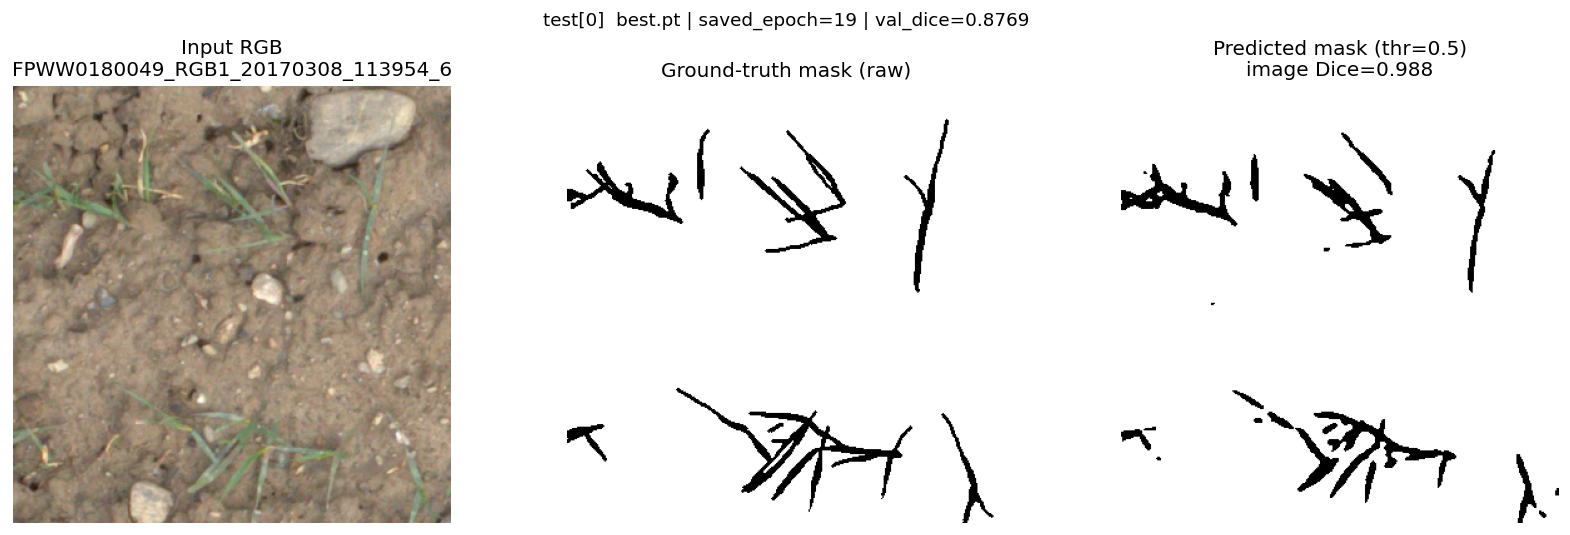

Saved: D:\Cursor\AR-SSL4M\EWS\data\finetune_seg_ckpts_notebook_geom\viz_test_000_FPWW0180049_RGB1_20170308_113954_6.png


In [58]:
import re

import matplotlib.pyplot as plt
import numpy as np

best_ckpt_path = OUT_DIR / SEG_BEST_NAME
if not best_ckpt_path.is_file():
    raise FileNotFoundError(f"Train first; missing {best_ckpt_path}")

try:
    ck_viz = torch.load(best_ckpt_path, map_location=device, weights_only=False)
except TypeError:
    ck_viz = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ck_viz["model"])
model.eval()

idx = int(VIZ_TEST_INDEX) % len(ds_te)
stem = ds_te.stems[idx]
x, y_gt = ds_te[idx]

with torch.no_grad():
    logit = model(x.unsqueeze(0).to(device))
    prob = torch.sigmoid(logit).squeeze().float().cpu().numpy()

img = np.clip(x.permute(1, 2, 0).numpy(), 0.0, 1.0)
gt = y_gt.squeeze(0).numpy()
pred_bin = (prob >= float(VIZ_MASK_THRESHOLD)).astype(np.float32)

inter = (pred_bin * gt).sum()
dice_1 = (2 * inter + 1e-6) / (pred_bin.sum() + gt.sum() + 1e-6)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), dpi=120)
axes[0].imshow(img)
axes[0].set_title(f"Input RGB\n{stem}")
axes[0].axis("off")

axes[1].imshow(gt, cmap="gray", vmin=0.0, vmax=1.0)
axes[1].set_title("Ground-truth mask (raw)")
axes[1].axis("off")

axes[2].imshow(pred_bin, cmap="gray", vmin=0.0, vmax=1.0)
axes[2].set_title(
    f"Predicted mask (thr={VIZ_MASK_THRESHOLD})\nimage Dice={float(dice_1):.3f}"
)
axes[2].axis("off")

ep = ck_viz.get("epoch", "?")
vd = ck_viz.get("val_dice", None)
sub = f"best.pt | saved_epoch={ep}"
if vd is not None:
    sub += f" | val_dice={float(vd):.4f}"
fig.suptitle(f"test[{idx}]  {sub}", fontsize=11)
plt.tight_layout()

safe_stem = re.sub(r"[^\w\-.]+", "_", stem)[:80]
out_png = OUT_DIR / f"viz_test_{idx:03d}_{safe_stem}.png"
plt.savefig(out_png, bbox_inches="tight")
plt.show()
print("Saved:", out_png.resolve())

